In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import glob
import h5py
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import random
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA
from torchvision.transforms import v2


rng = random.Random(42)

In [5]:
TELLU_PATH = 'data/tellu.h5'
ORGAQUANT_PATH = 'data/orgaquant.h5'
MULTIORG_PATH = 'data/multiorg.h5'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Attention Maps

### Test on Dinov2

In [3]:
# DINOv2 - ViT-S/14
MODEL_URL = 'facebookresearch/dinov2'
MODEL = 'dinov2_vits14'

# Img transformation to match model's expected input
img_size = 448 
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the DINOv2 model
model = torch.hub.load(MODEL_URL, MODEL).to(DEVICE)
model.eval()

Using cache found in C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

Generating attention maps for Dinov2...


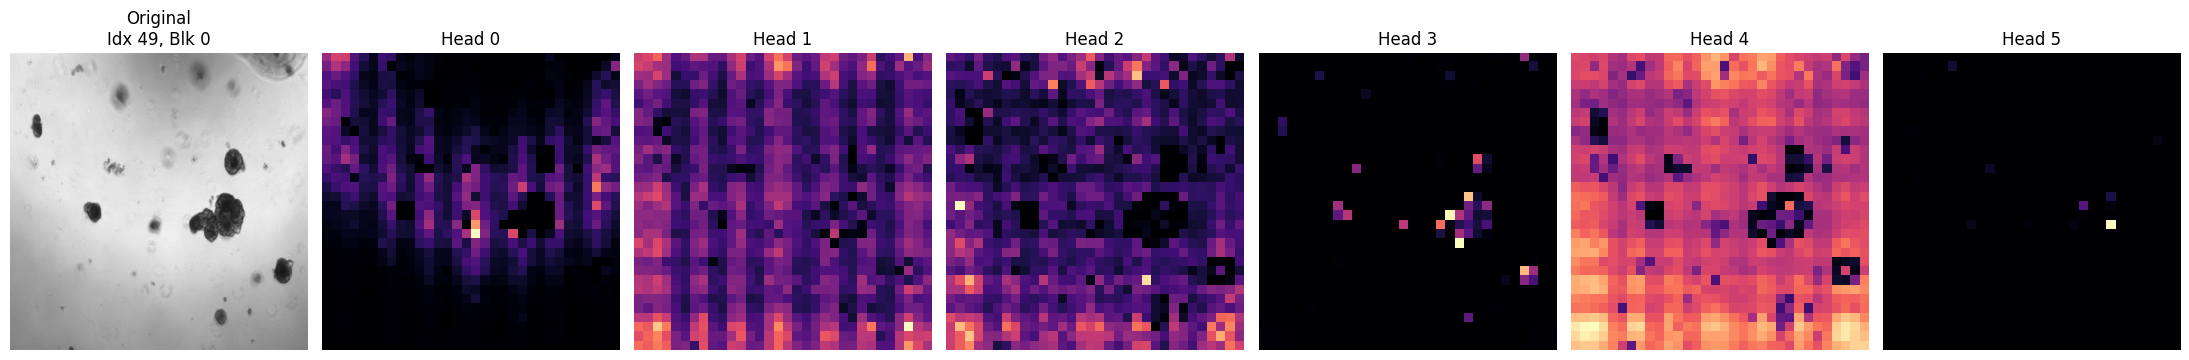

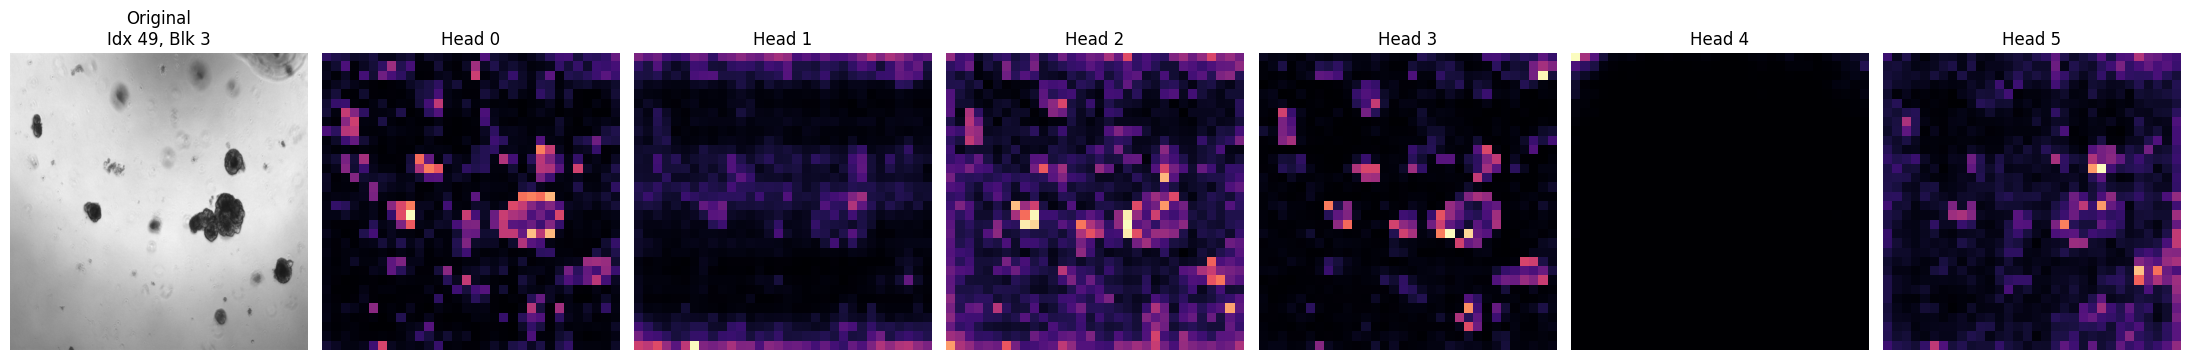

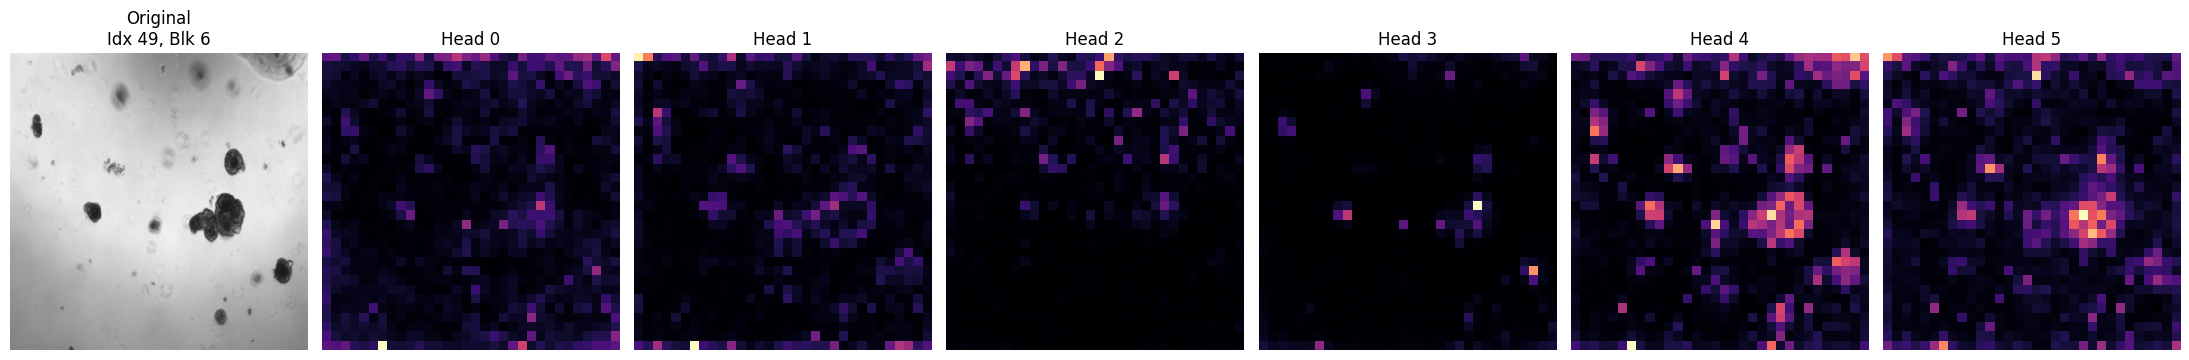

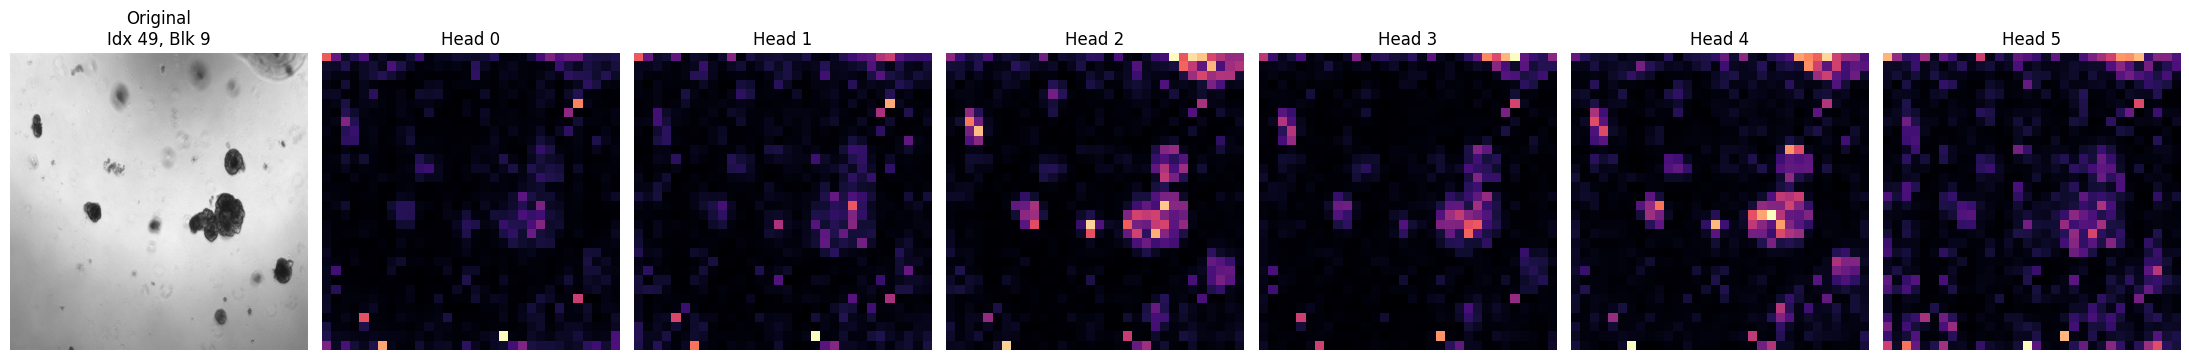

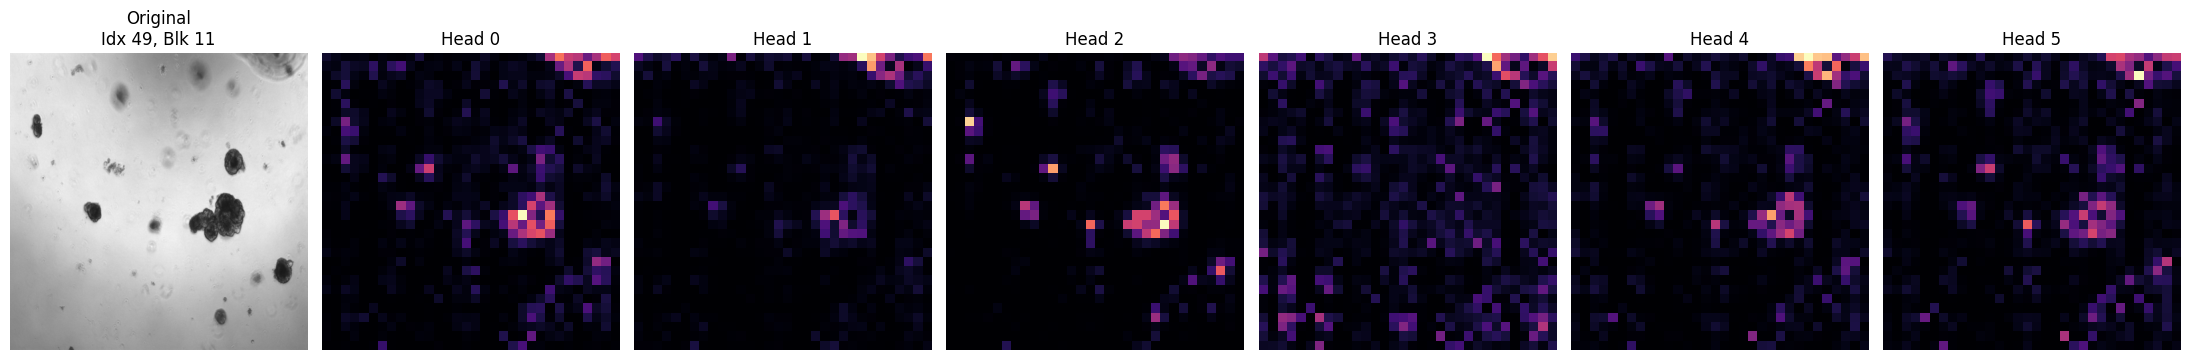

In [4]:
from tools.attention import AttentionVisualizer
import os

visualizer = AttentionVisualizer(device=DEVICE)

print("Generating attention maps for Dinov2...")
for i in [0, 3, 6, 9, 11]:
    visualizer.get_attention_maps(model, transform, h5_path=TELLU_PATH,  img_index=49, block_index=i, img_size=img_size)


### Test on Dinov3

In [19]:
# Paths configuration
REPO_DIR = 'dinov3'
WEIGHTS_DIR = 'weights'


In [20]:
def load_dinov3_model(model_pattern,REPO_DIR=REPO_DIR, WEIGHTS_DIR=WEIGHTS_DIR, DEVICE=DEVICE):
    """Load the dinov3 model matching the given pattern from local weights.
    inputs:
        model_pattern (str): Pattern to identify the model weights file (e.g., 'vits16plus').
        REPO_DIR (str): Path to the local dinov3 repository.
        WEIGHTS_DIR (str): Path to the directory containing model weights.
        DEVICE (torch.device): Device to load the model onto.
    returns:
        model (torch.nn.Module): Loaded DINOv3 model.
    """
    # Identify the corresponding model weights file (e.g., 'vits16plus')
    search_pattern = os.path.join(WEIGHTS_DIR, f"*_{model_pattern}_*.pth")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"Error: No weights file found for pattern '{model_pattern}' in {WEIGHTS_DIR}.")
        return None
        
    checkpoint_path = files[0] # First file found
    entrypoint = f"dinov3_{model_pattern}"
    
    print(f"Loading {entrypoint} from {os.path.basename(checkpoint_path)}")

    # Load via torch.hub
    model = torch.hub.load(
        REPO_DIR, 
        entrypoint, 
        source='local', 
        weights=os.path.abspath(checkpoint_path)
    ).to(DEVICE)
    
    model.eval()
    return model



def make_transform(resize_size: int = 256):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

In [21]:
# Possible versions include : vits16, vits16plus, vitb16, vitl16, vit16plus, vit7b16
model = load_dinov3_model("vits16plus")
model.eval()

Loading dinov3_vits16plus from dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=384, out_features=1536, bias=True)
        (w2): Linear(in_features=384, out_features=1536, bias=True)
        (w3): Linear(in_features=1536, out_features=384, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((384,), ep

In [22]:
img_size = 448
transform = make_transform(img_size)

Generating attention maps for Dinov3...


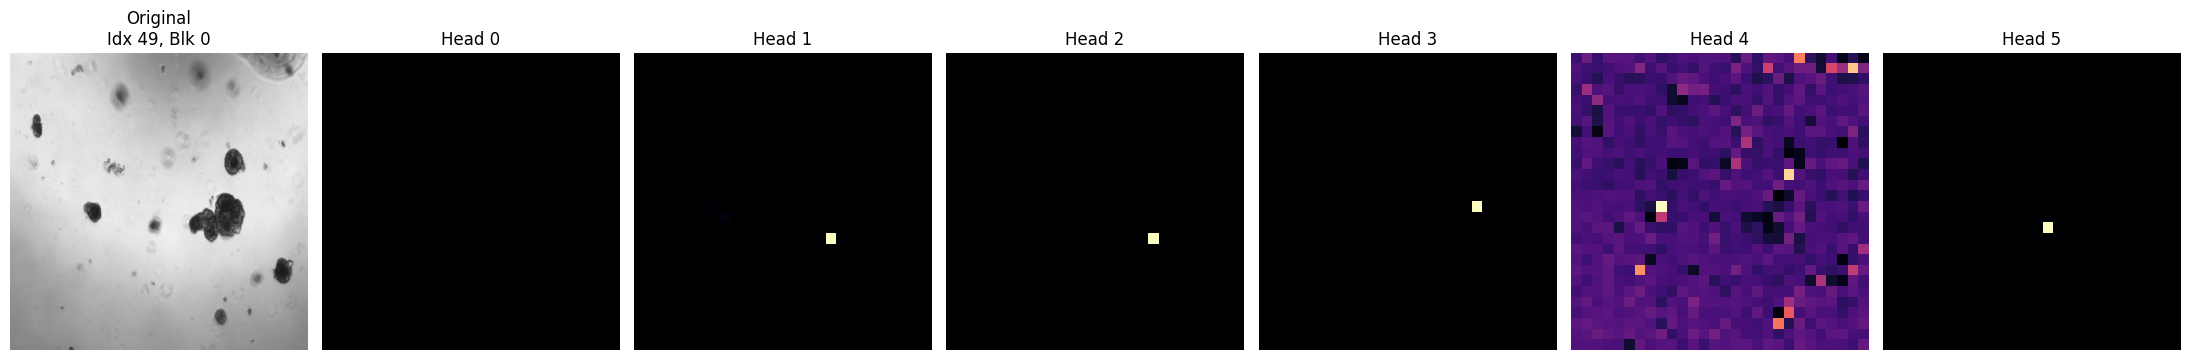

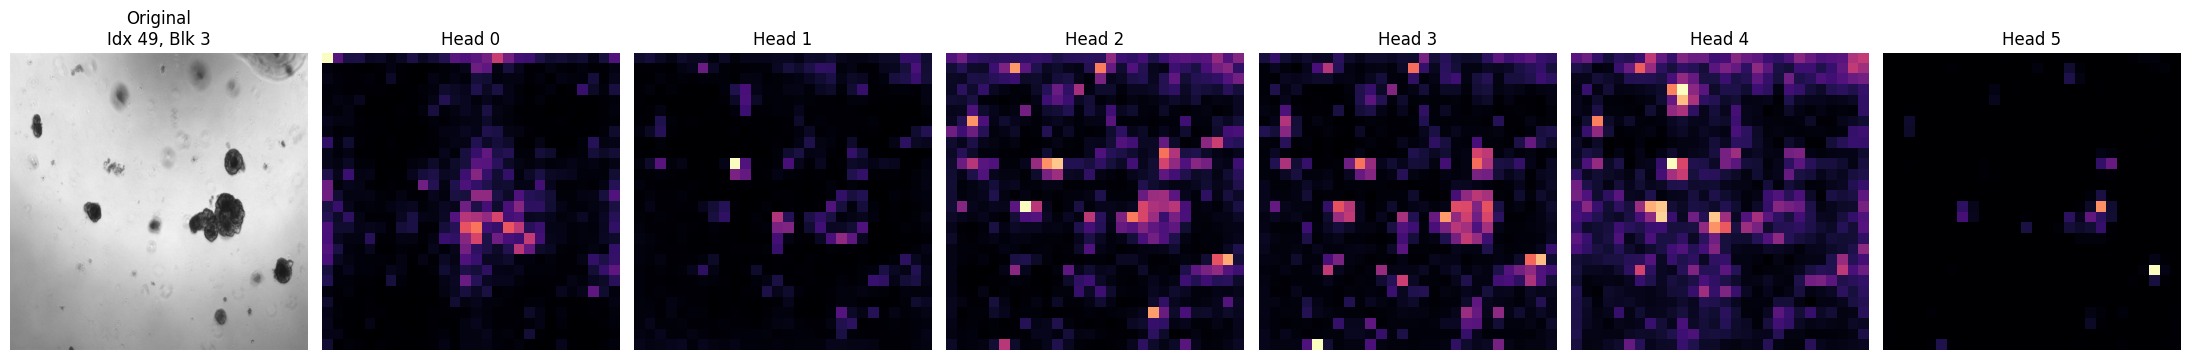

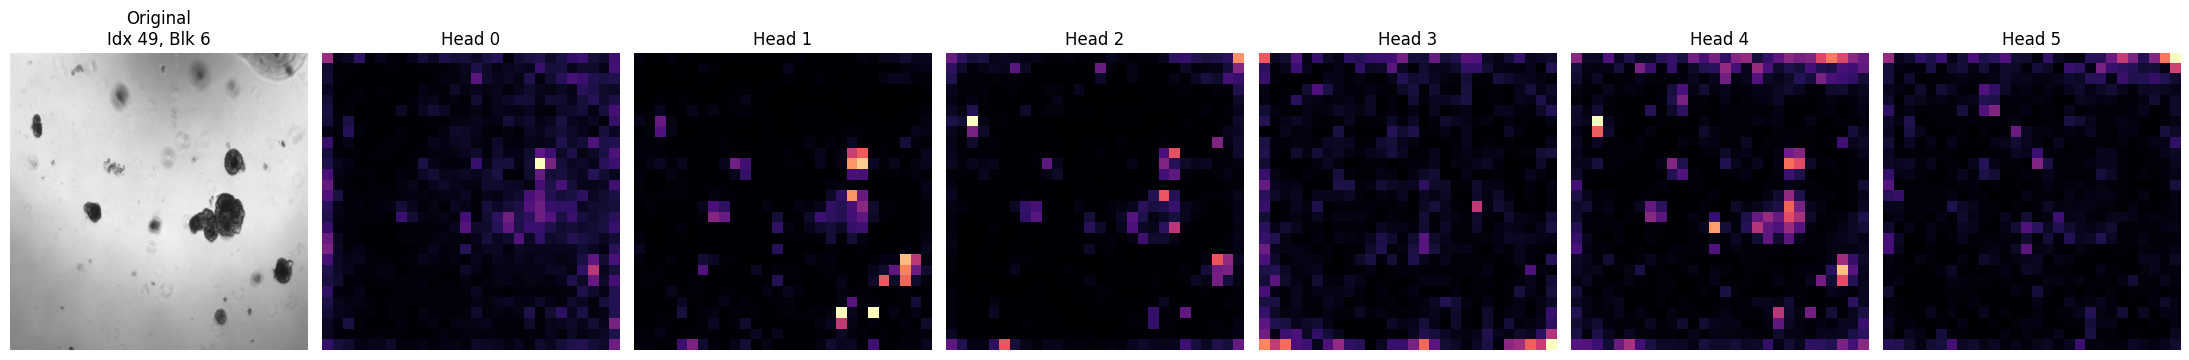

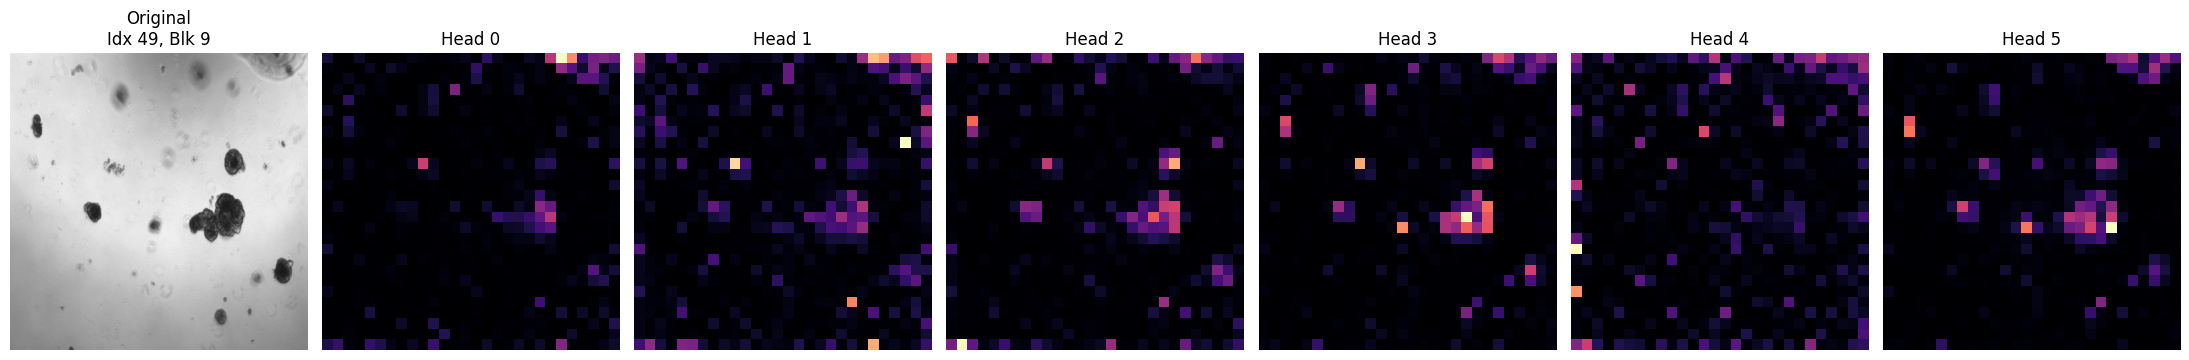

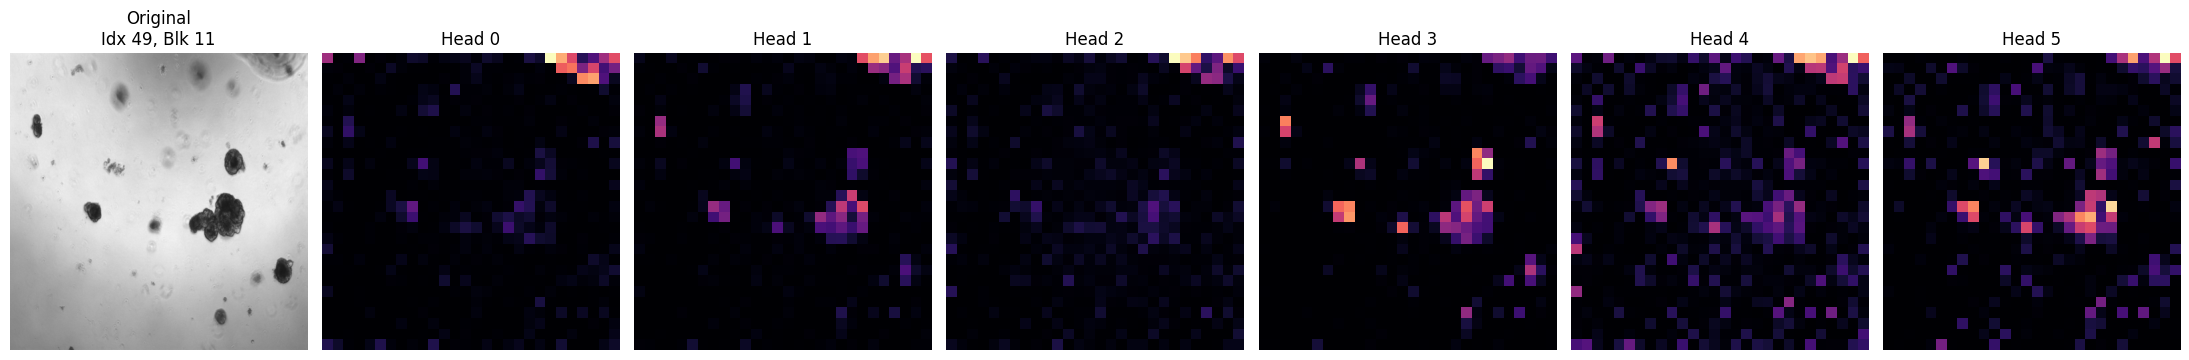

In [23]:
from tools.attention import AttentionVisualizer

visualizer = AttentionVisualizer(device=DEVICE)

print("Generating attention maps for Dinov3...")

for i in [0, 3, 6, 9, 11]:
    visualizer.get_attention_maps(model, transform, h5_path=TELLU_PATH,  img_index=49, block_index=i, img_size=img_size)


Attention MAPS obtained originally

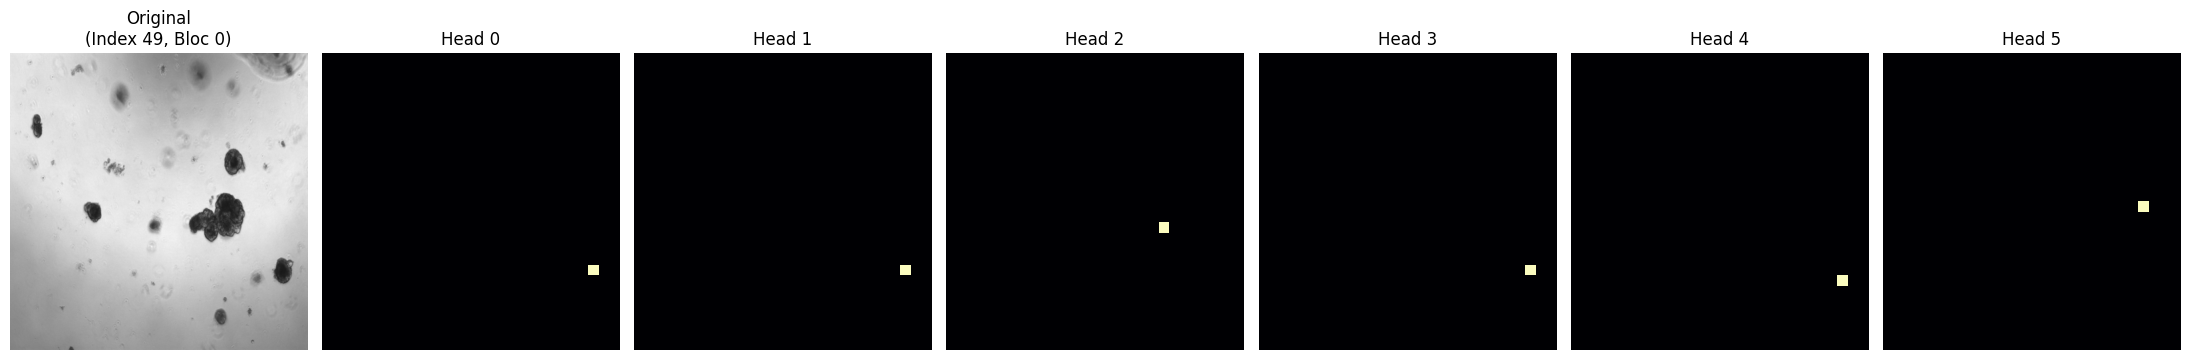

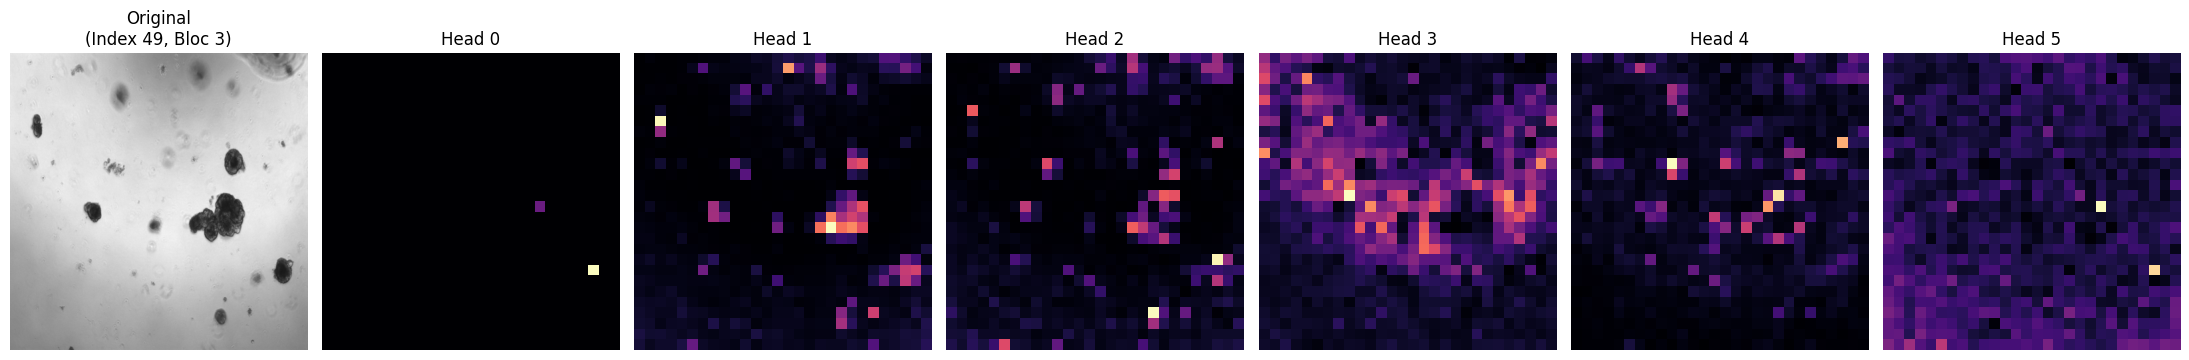

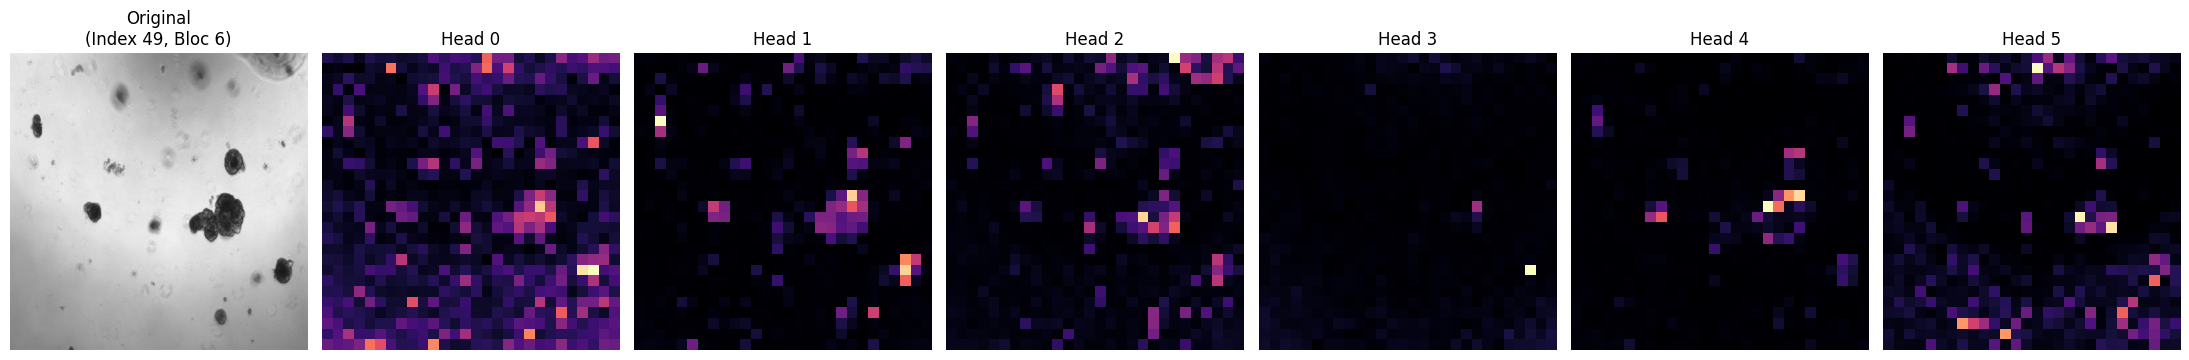

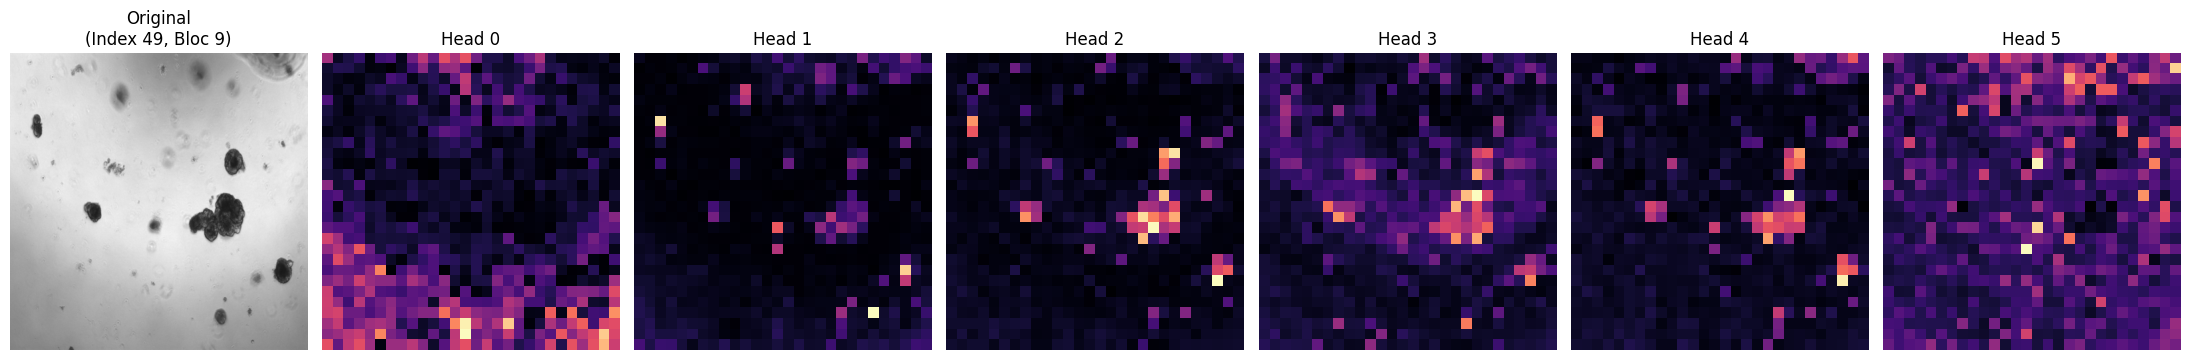

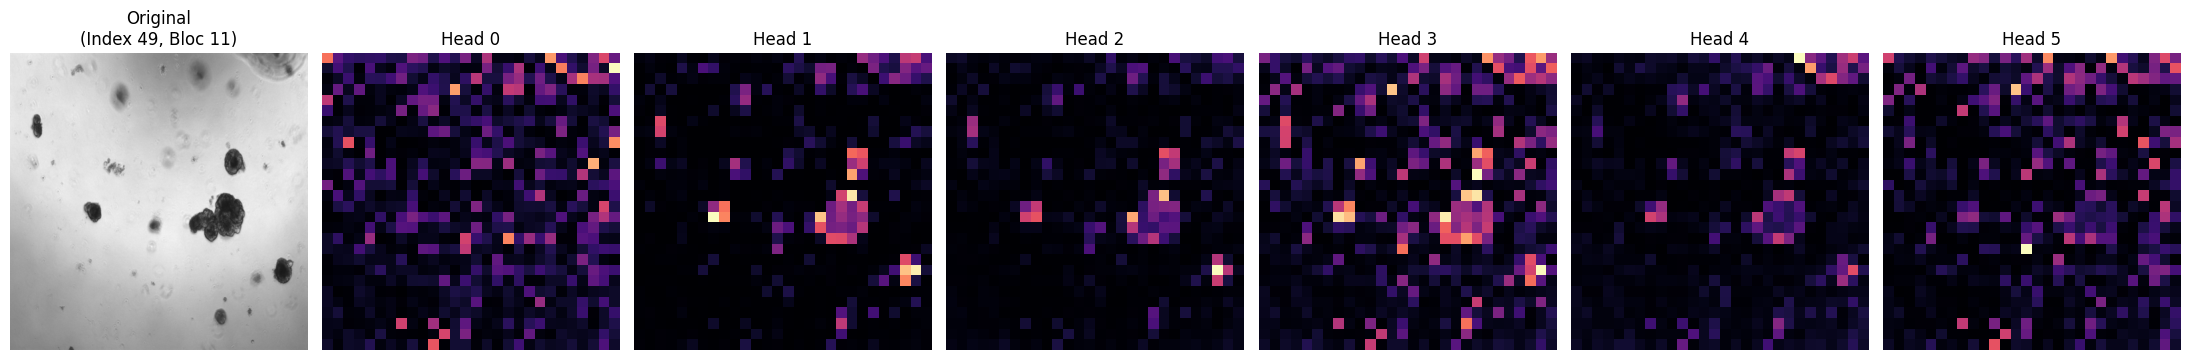

### Test on Curia

In [ ]:
from huggingface_hub import login

MODEL_URL = 'raidium/curia'
HF_TOKEN = 'YOUR_TOKEN_HERE'  # Replace with your actual Hugging Face token
login(token=HF_TOKEN)

In [31]:
from transformers import AutoModel

model = AutoModel.from_pretrained(MODEL_URL,trust_remote_code=True).to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Dinov2DropPath(p=0.4)
        (norm2): LayerNorm((768,), eps

In [32]:
# Img transformation for Curia (1 channel)
img_size = 448 

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    # Make sure the image is grayscale before converting to tensor
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),
    # Normalization for single channel
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

Generating attention maps for Curia...


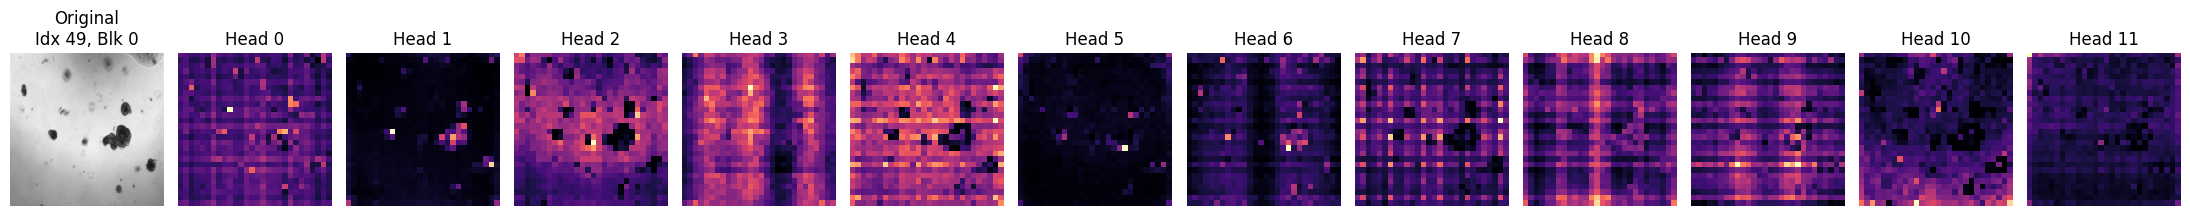

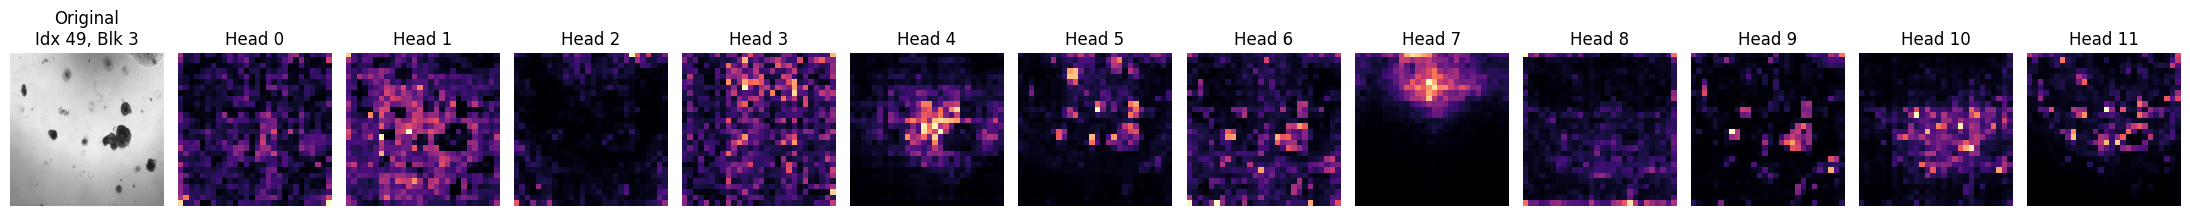

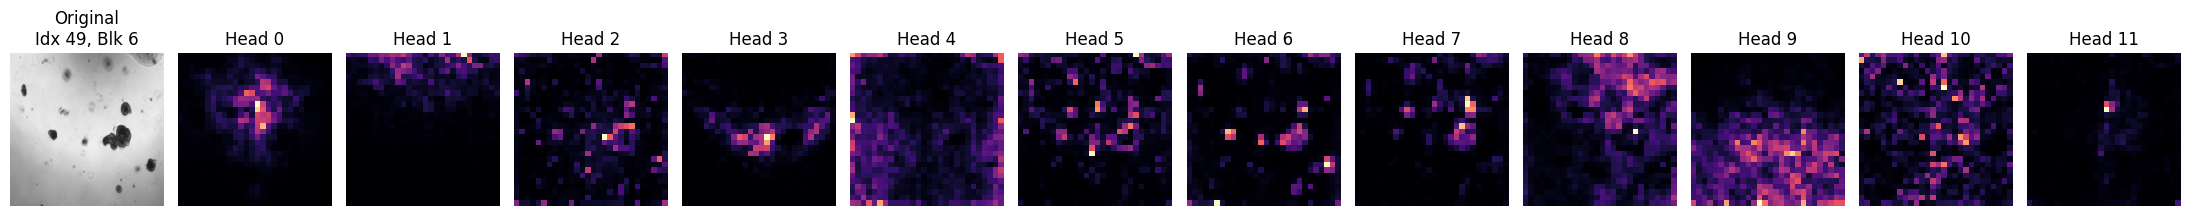

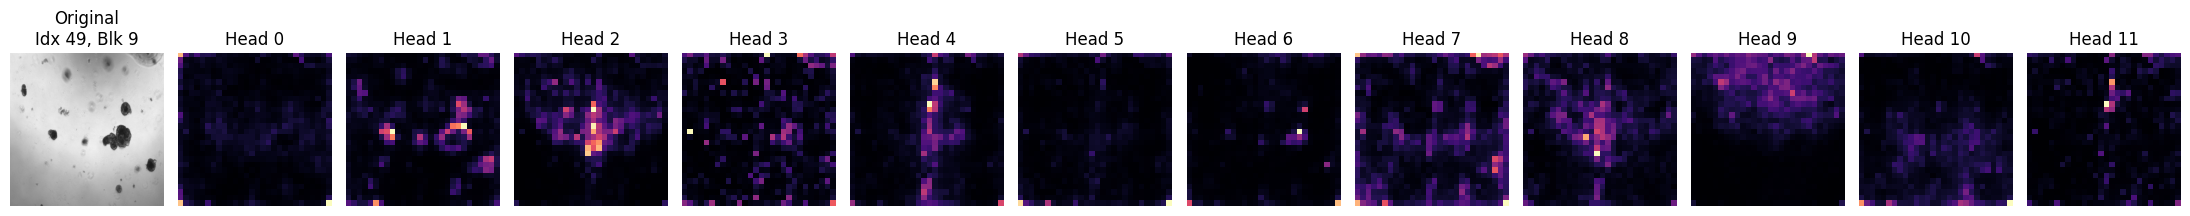

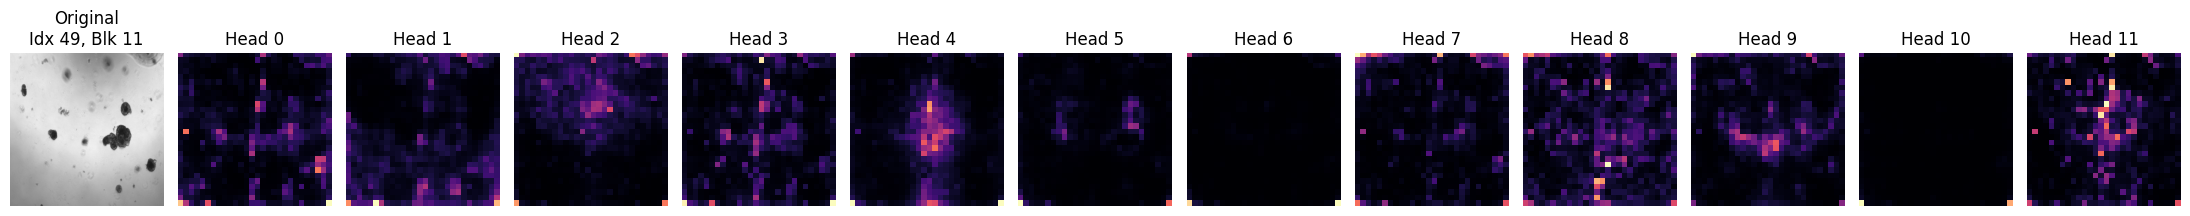

In [33]:
from tools.attention import AttentionVisualizer
import os

visualizer = AttentionVisualizer(device=DEVICE)

print("Generating attention maps for Curia...")
for i in [0, 3, 6, 9, 11]:
    visualizer.get_attention_maps(model, transform, TELLU_PATH,  img_index=49, block_index=i, img_size=img_size)


Attention MAPS obtained originally

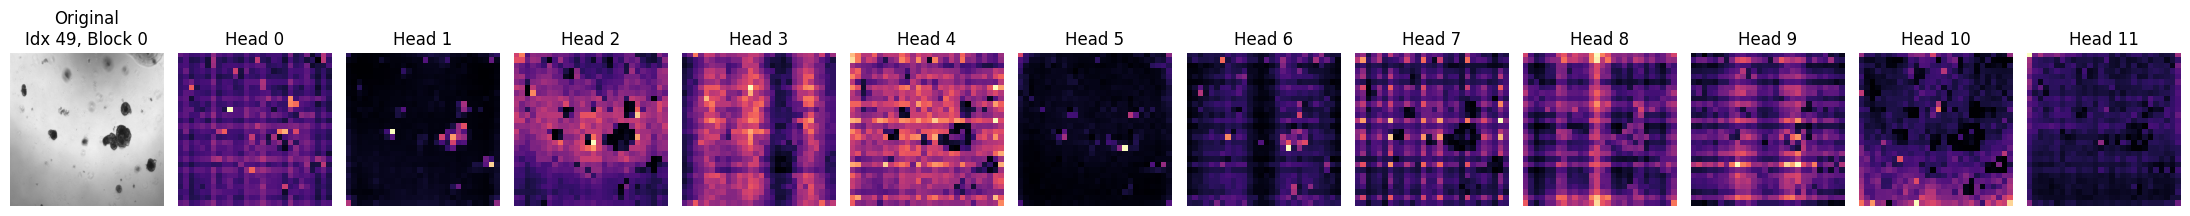

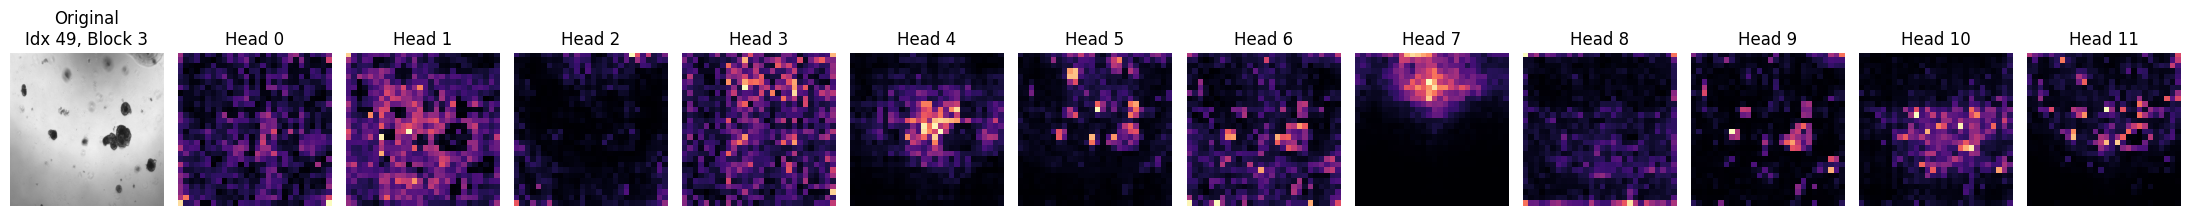

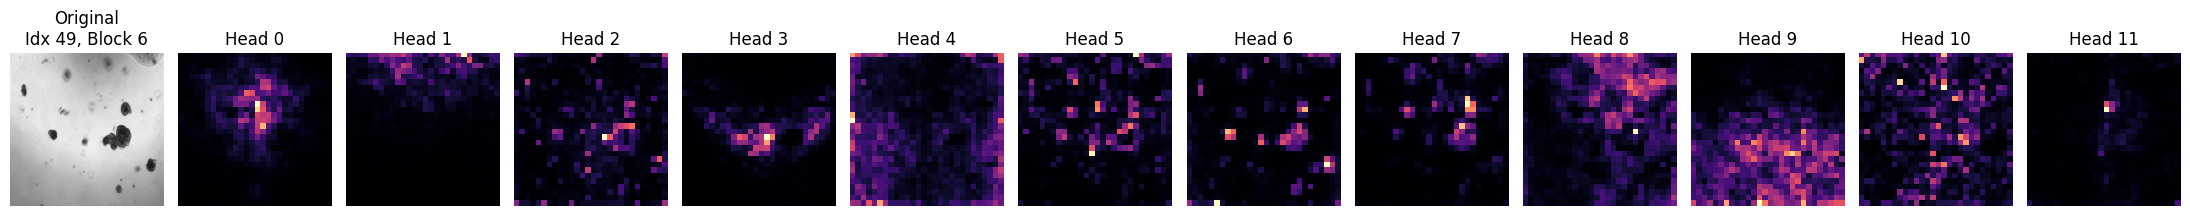

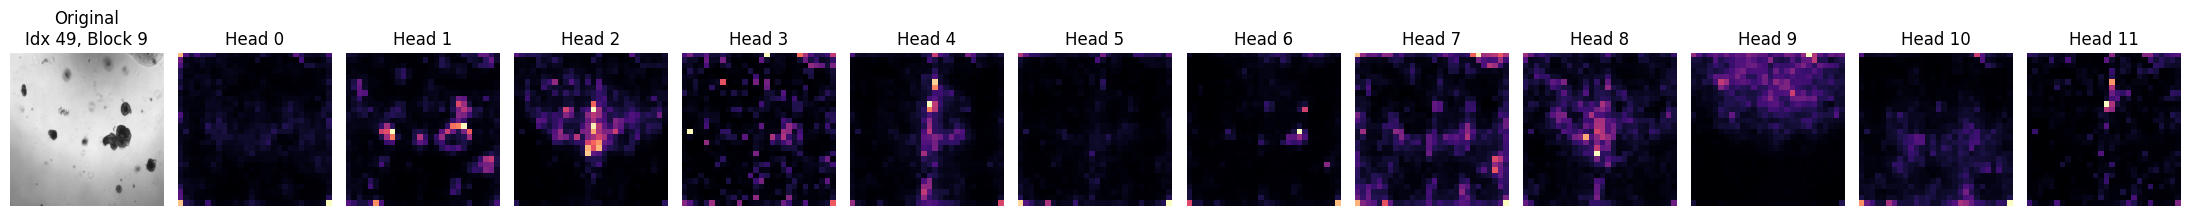

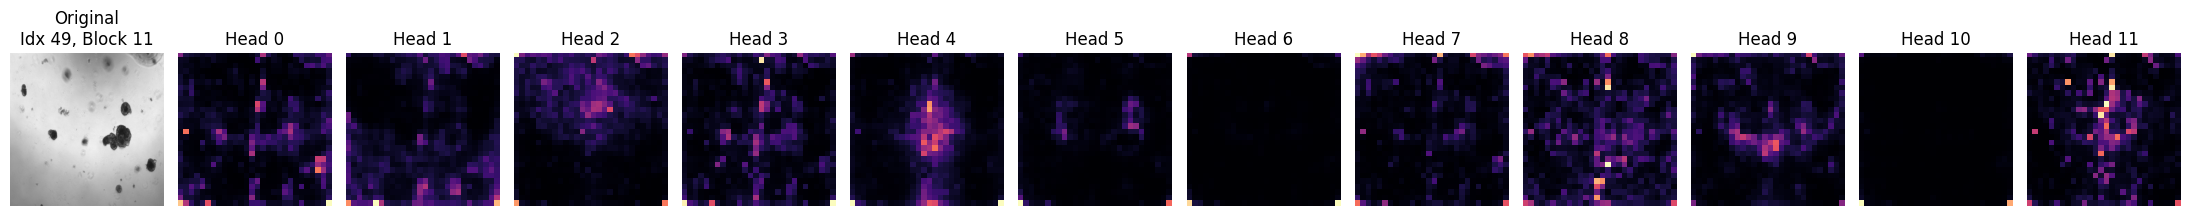

### Test on Dinov2

In [ ]:
# DINOv2 - ViT-S/14
MODEL_URL = 'facebookresearch/dinov2'
MODEL = 'dinov2_vits14'

# Img transformation to match model's expected input
img_size = 448 
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the DINOv2 model
model = torch.hub.load(MODEL_URL, MODEL).to(DEVICE)
model.eval()

Using cache found in C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

## PCA Maps

### Test on Dinov2

In [6]:
# DINOv2 - ViT-S/14
MODEL_URL = 'facebookresearch/dinov2'
MODEL = 'dinov2_vits14'

# Img transformation to match model's expected input
img_size = 448 
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the DINOv2 model
model = torch.hub.load(MODEL_URL, MODEL).to(DEVICE)
model.eval()

Using cache found in C:\Users\DELL/.cache\torch\hub\facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

Generating PCA semantic maps for the model...


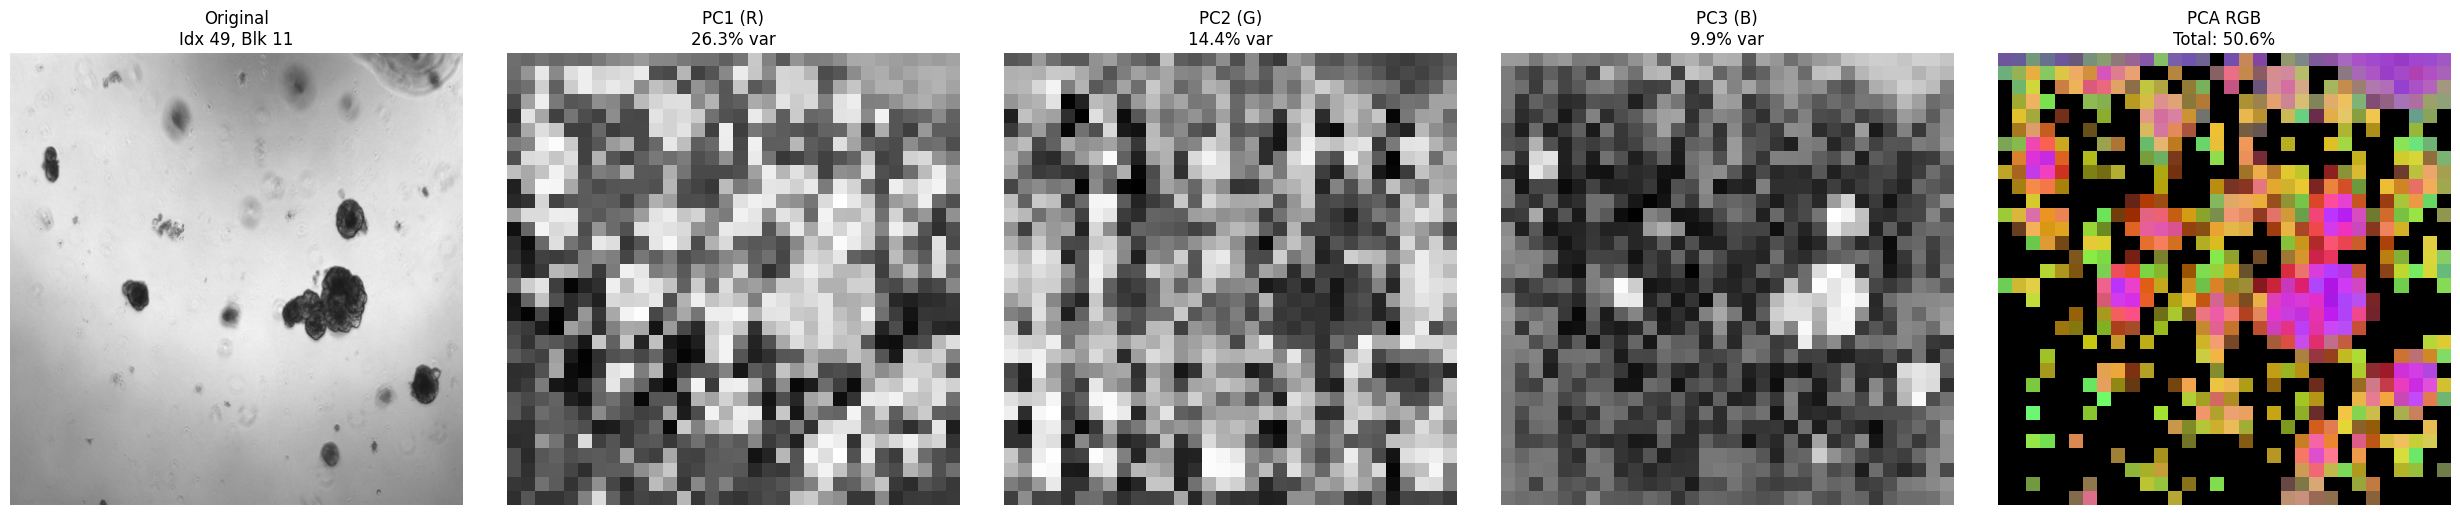

Explained variance: 50.61%
Foreground: 57.2% of image


In [9]:
from tools.pca import PCAVisualizer

# Initialize the PCA tool
pca_tool = PCAVisualizer(device=DEVICE)

print("Generating PCA semantic maps for the model...")

pca_tool.get_pca_maps(
    model, 
    transform, 
    h5_path=TELLU_PATH, 
    img_index=49, 
    block_index=11, 
    img_size=img_size,
    bg_threshold=0.4,
    invert_pc=False  # Usually needed for PDOs to get colored objects on black bg
)

PCA obtained originally

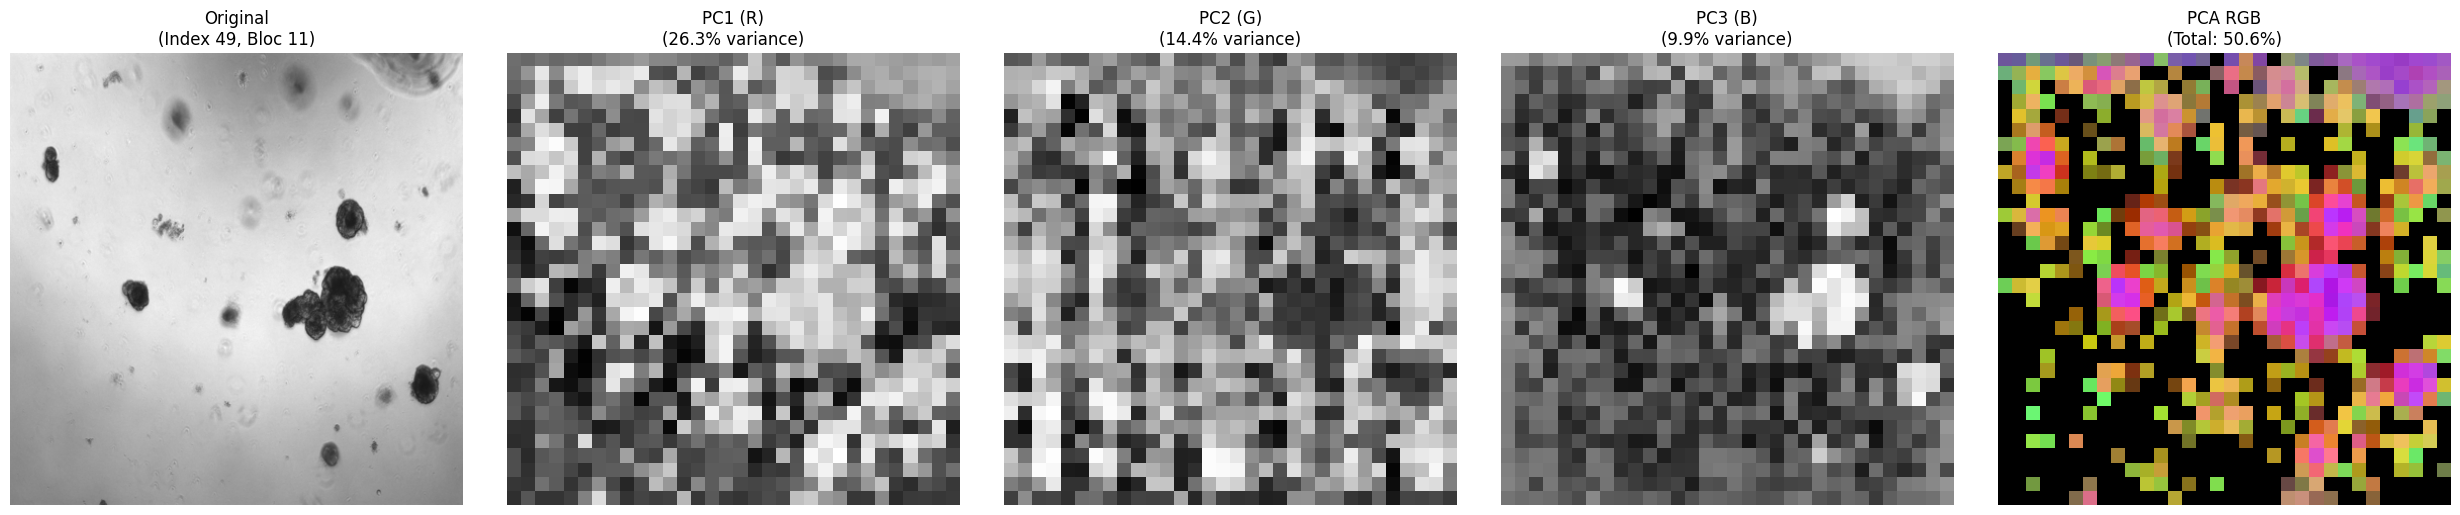

Total explained variance: 50.61% 
\
Foreground pixels: 586 / 1024 (57.2%)

### Test on Dinov3

In [10]:
# Paths configuration
REPO_DIR = 'dinov3'
WEIGHTS_DIR = 'weights'


In [17]:
def load_dinov3_model(model_pattern,REPO_DIR=REPO_DIR, WEIGHTS_DIR=WEIGHTS_DIR, DEVICE=DEVICE):
    """Load the dinov3 model matching the given pattern from local weights.
    inputs:
        model_pattern (str): Pattern to identify the model weights file (e.g., 'vits16plus').
        REPO_DIR (str): Path to the local dinov3 repository.
        WEIGHTS_DIR (str): Path to the directory containing model weights.
        DEVICE (torch.device): Device to load the model onto.
    returns:
        model (torch.nn.Module): Loaded DINOv3 model.
    """
    # Identify the corresponding model weights file (e.g., 'vits16plus')
    search_pattern = os.path.join(WEIGHTS_DIR, f"*_{model_pattern}_*.pth")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"Error: No weights file found for pattern '{model_pattern}' in {WEIGHTS_DIR}.")
        return None
        
    checkpoint_path = files[0] # First file found
    entrypoint = f"dinov3_{model_pattern}"
    
    print(f"Loading {entrypoint} from {os.path.basename(checkpoint_path)}")

    # Load via torch.hub
    model = torch.hub.load(
        REPO_DIR, 
        entrypoint, 
        source='local', 
        weights=os.path.abspath(checkpoint_path)
    ).to(DEVICE)
    
    model.eval()
    return model



def make_transform(resize_size: int = 256):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

In [24]:
# Possible versions include : vits16, vits16plus, vitb16, vitl16, vit16plus, vit7b16
model = load_dinov3_model("vits16")
model.eval()

Loading dinov3_vits16 from dinov3_vits16_pretrain_lvd1689m-08c60483.pth


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

In [25]:
img_size = 448
transform = make_transform(img_size)

Generating PCA semantic maps for the model...


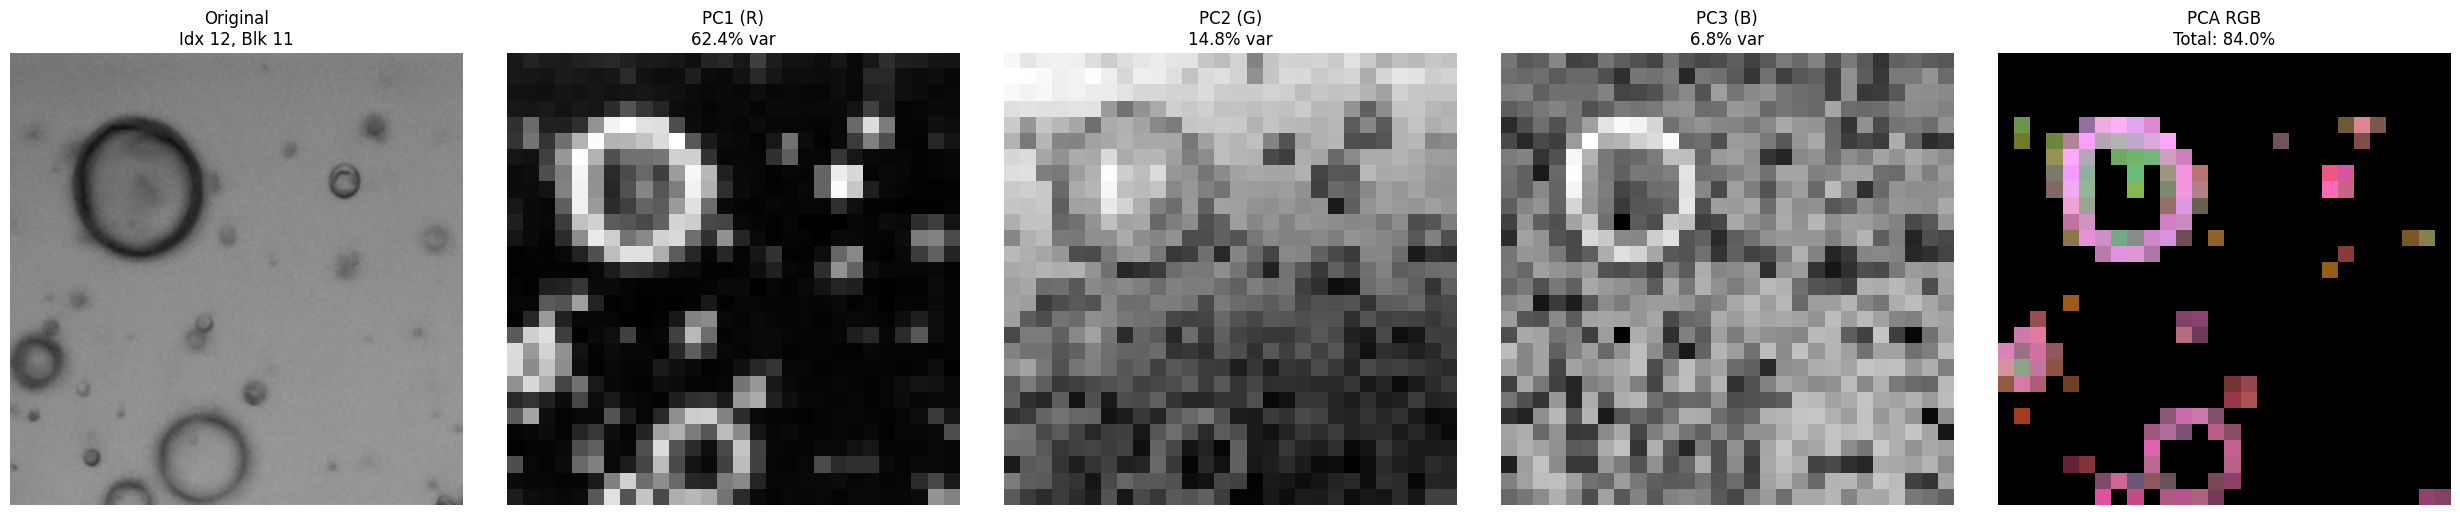

Explained variance: 83.99%
Foreground: 16.2% of image


In [30]:
from tools.pca import PCAVisualizer

# Initialize the PCA tool
pca_tool = PCAVisualizer(device=DEVICE)

print("Generating PCA semantic maps for the model...")

pca_tool.get_pca_maps(
    model, 
    transform, 
    h5_path=ORGAQUANT_PATH, 
    img_index=12, 
    block_index=11, 
    img_size=img_size,
    bg_threshold=0.4,
    invert_pc=True  # Usually needed for PDOs to get colored objects on black bg
)

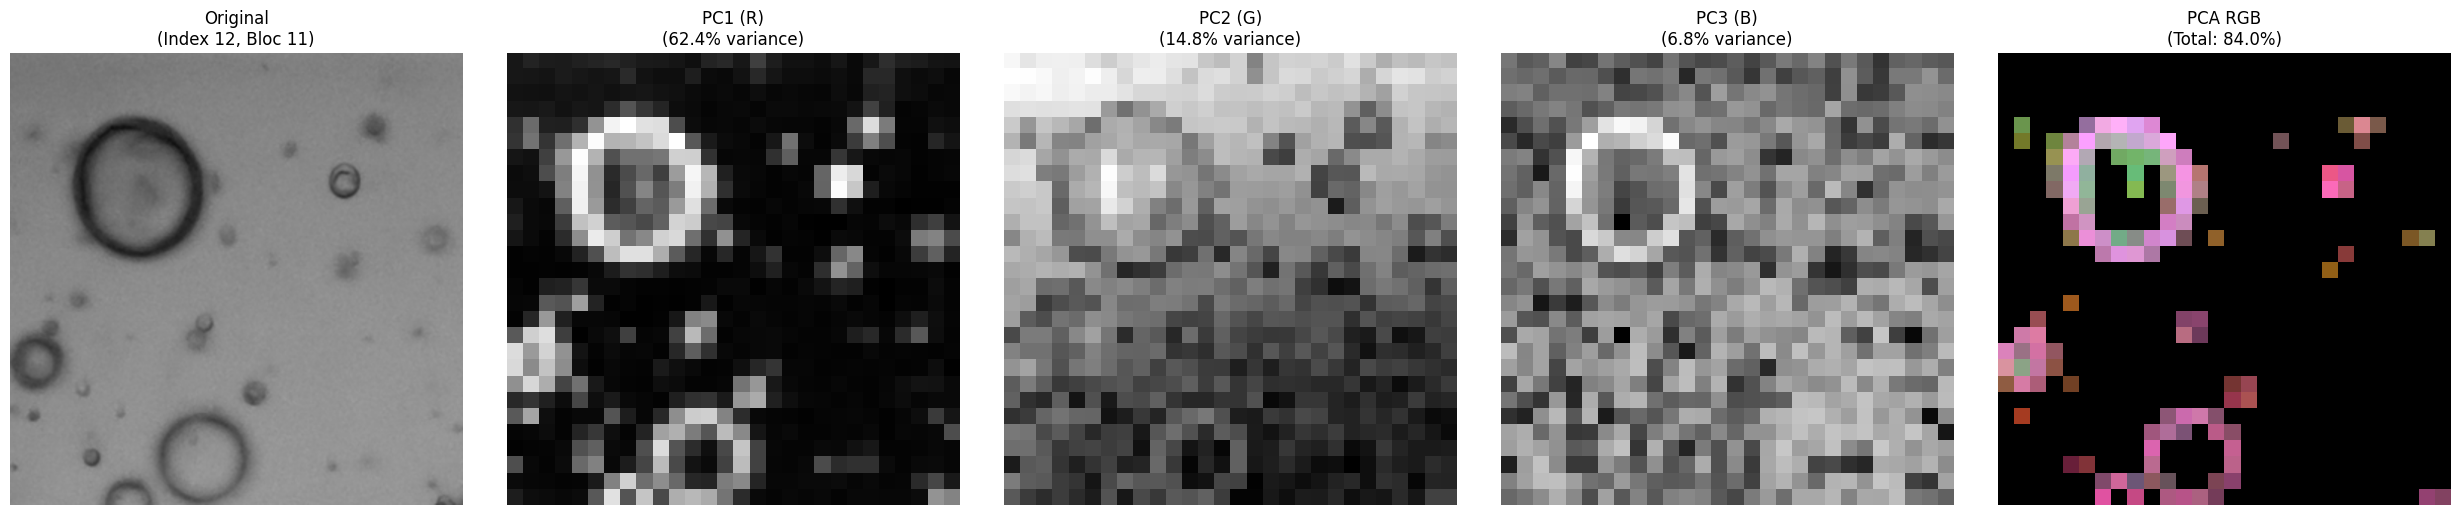

Explained variance: 83.99%
\
Foreground: 16.2% of image